In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mutual_info_score

In [2]:
data = 'wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

!wget $data -O course_lead_scoring_2026.csv

--2026-09-28 18:56:08--  http://wget/
Resolving wget (wget)... failed: No such host is known. .
wget: unable to resolve host address 'wget'
--2026-09-28 18:56:11--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: 'course_lead_scoring_2026.csv'

     0K .......... .......... .......... .......... .......... 18%  490K 0s
    50K .......... .......... .......... .......... .......... 36% 33.0M 0s
   100K .......... .......... .......... .......... .......... 55% 2.08M 0s
   150K .......... .......... .......... .......... .......... 73% 2.85M 0s
   200K .......... .......... .......... .......... ...

In [3]:
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   object 
 1   industry                  4760 non-null   object 
 2   employment_status         4806 non-null   object 
 3   location                  4792 non-null   object 
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [5]:
categorical = list(df.dtypes[df.dtypes == 'object'].index)
numerical = list(df.dtypes[df.dtypes != 'object'].index)
numerical.remove('converted')

for c in categorical:
    print(c, df[c].nunique(), list(df[c].unique()))

lead_source 5 ['organic_search', 'social_media', 'referral', 'paid_ads', nan, 'events']
industry 6 ['technology', 'retail', 'manufacturing', 'education', 'healthcare', nan, 'finance']
employment_status 4 ['employed', 'student', nan, 'unemployed', 'self_employed']
location 5 ['europe', 'south_america', nan, 'north_america', 'africa', 'asia']


In [6]:
df['converted'].unique()

array([1, 0])

In [7]:
# Data preparation
# Categorical columns: replace missing values with 'NA', numerical columns: replace missing values with 0

for col in df.columns:
    if col in categorical and df[col].isnull().any():
        df[col] = df[col].fillna('NA')
    elif col in numerical and df[col].isnull().any():
        df[col] = df[col].fillna(0)
        
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   object 
 1   industry                  5000 non-null   object 
 2   employment_status         5000 non-null   object 
 3   location                  5000 non-null   object 
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


In [8]:
# Q1. Most frequent value (mode) of column `industry`

print(f'Most frequent industry: {df['industry'].mode()[0]}')
display(df['industry'].value_counts().to_frame())

Most frequent industry: technology


,count
industry,
technology,1173
retail,925
healthcare,840
finance,720
education,639
manufacturing,463
NA,240


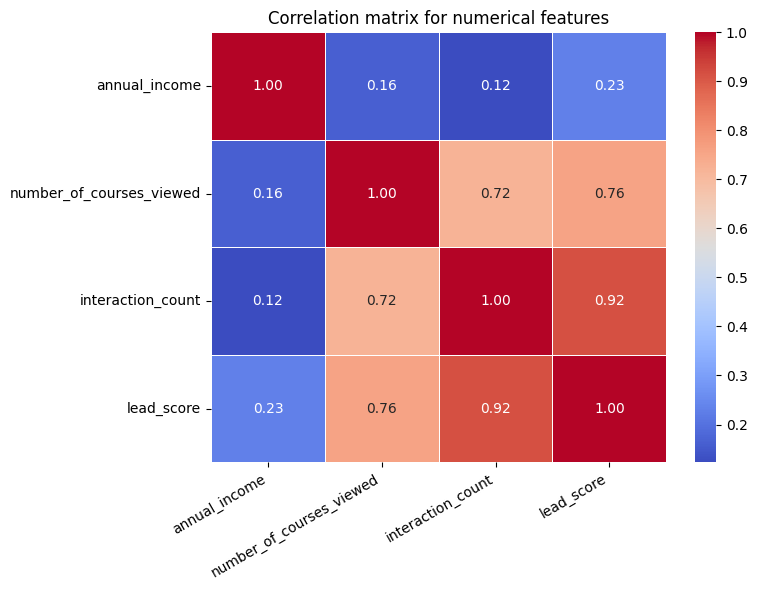

In [9]:
# Q2. Correlation matrix for numerical features

corr_matrix = df[numerical].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix for numerical features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show();

From the correlation matrix, we see that `interaction_count` and `lead_score` are the two numerical features with the largest correlation at 0.92.

In [10]:
# Split the data into 60/20/20 training/validation/test

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [11]:
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [12]:
# EDA: for each categorical variable, compare conversion rate between groups

global_conversion_rate = df_full_train['converted'].mean()

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c)['converted'].agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_conversion_rate
    df_group['ratio (group over global)'] = df_group['mean'] / global_conversion_rate
    display(df_group.sort_values('ratio (group over global)', ascending=False))
    print()

lead_source


,mean,count,diff,ratio (group over global)
lead_source,,,,
referral,0.763844,614,0.193094,1.338316
organic_search,0.677579,1008,0.106829,1.187174
NA,0.610169,118,0.039419,1.069066
social_media,0.547962,834,-0.022788,0.960073
paid_ads,0.427957,930,-0.142793,0.749815
events,0.411290,496,-0.159460,0.720614



industry


,mean,count,diff,ratio (group over global)
industry,,,,
finance,0.613402,582,0.042652,1.074730
technology,0.611111,918,0.040361,1.070716
NA,0.587629,194,0.016879,1.029573
healthcare,0.559398,665,-0.011352,0.980111
retail,0.553741,735,-0.017009,0.970200
manufacturing,0.548969,388,-0.021781,0.961838
education,0.500000,518,-0.070750,0.876040



employment_status


,mean,count,diff,ratio (group over global)
employment_status,,,,
employed,0.656459,2090,0.085709,1.150170
NA,0.580247,162,0.009497,1.016639
self_employed,0.548276,580,-0.022474,0.960623
unemployed,0.435572,551,-0.135178,0.763157
student,0.419773,617,-0.150977,0.735476



location


,mean,count,diff,ratio (group over global)
location,,,,
NA,0.603550,169,0.032800,1.057469
asia,0.585308,844,0.014558,1.025507
europe,0.584821,896,0.014071,1.024654
north_america,0.576923,1092,0.006173,1.010816
africa,0.546154,390,-0.024596,0.956906
south_america,0.525452,609,-0.045298,0.920633


In [13]:
# Q3. Mutual information between `converted` and each categorical variable, using only training set

def mutual_info_score_converted(series):
    return mutual_info_score(series, df_full_train['converted'])

mi = df_full_train[categorical].apply(mutual_info_score_converted)
mi.sort_values(ascending=False)

lead_source          0.034761
employment_status    0.020313
industry             0.002898
location             0.001050
dtype: float64

`lead_source` has the highest mutual information score with `converted`.

In [14]:
df_train[numerical].describe()

,annual_income,number_of_courses_viewed,interaction_count,lead_score
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,49918.779000,2.055333,4.417333,0.486553
std,24877.547535,1.175896,2.433339,0.201951
min,0.000000,0.000000,0.000000,0.000000
25%,34726.000000,1.000000,3.000000,0.340000
50%,51582.500000,2.000000,4.000000,0.480000
75%,69015.000000,3.000000,6.000000,0.622500
max,107205.000000,6.000000,13.000000,0.990000


In [15]:
# Q4. Train a logistic regression model

preprocessor = ColumnTransformer(
    transformers = [
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('numerical', StandardScaler(), numerical)
    ]
)

model0 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', 
                                      C=1.0, 
                                      max_iter=1000, 
                                      random_state=42))
])

model0.fit(df_train, y_train)

# Compute accuracy on validation set
y_pred0 = model0.predict(df_val)
accuracy0 = (y_pred0 == y_val).mean()
print(f'Validation accuracy of model0, base model: {accuracy0:.2f}')


Validation accuracy of model0, base model: 0.73


In [16]:
# Get feature names after one-hot encoding
feature_names = model0.named_steps['preprocessor'].get_feature_names_out()

# Get intercept and coefficients of the model
intercept = model0.named_steps['classifier'].intercept_[0]
coef = model0.named_steps['classifier'].coef_[0]

print('model0 (base logistic regression model):')
print(f'\nFeatures after one-hot encoding: {feature_names}')
print(f'\nIntercept: {intercept}')
print(f'\nCoefficients: {coef}')

model0 (base logistic regression model):

Features after one-hot encoding: ['categorical__lead_source_NA' 'categorical__lead_source_events'
 'categorical__lead_source_organic_search'
 'categorical__lead_source_paid_ads' 'categorical__lead_source_referral'
 'categorical__lead_source_social_media' 'categorical__industry_NA'
 'categorical__industry_education' 'categorical__industry_finance'
 'categorical__industry_healthcare' 'categorical__industry_manufacturing'
 'categorical__industry_retail' 'categorical__industry_technology'
 'categorical__employment_status_NA'
 'categorical__employment_status_employed'
 'categorical__employment_status_self_employed'
 'categorical__employment_status_student'
 'categorical__employment_status_unemployed' 'categorical__location_NA'
 'categorical__location_africa' 'categorical__location_asia'
 'categorical__location_europe' 'categorical__location_north_america'
 'categorical__location_south_america' 'numerical__annual_income'
 'numerical__number_of_course

In [17]:
feature_coef0 = dict(zip(feature_names, coef.round(3)))
sorted_feature_coef0 = dict(sorted(feature_coef0.items(), 
                                   key=lambda item: item[1], 
                                   reverse=True))
sorted_feature_coef0

{'numerical__lead_score': np.float64(0.548),
 'numerical__interaction_count': np.float64(0.462),
 'categorical__lead_source_referral': np.float64(0.385),
 'categorical__employment_status_employed': np.float64(0.275),
 'categorical__lead_source_organic_search': np.float64(0.223),
 'categorical__location_NA': np.float64(0.222),
 'numerical__number_of_courses_viewed': np.float64(0.199),
 'categorical__industry_technology': np.float64(0.18),
 'categorical__employment_status_NA': np.float64(0.139),
 'categorical__industry_finance': np.float64(0.135),
 'categorical__location_north_america': np.float64(0.127),
 'categorical__lead_source_NA': np.float64(0.121),
 'categorical__industry_NA': np.float64(0.1),
 'categorical__employment_status_unemployed': np.float64(0.091),
 'numerical__annual_income': np.float64(0.088),
 'categorical__location_asia': np.float64(0.072),
 'categorical__location_europe': np.float64(0.07),
 'categorical__industry_retail': np.float64(0.065),
 'categorical__employment_

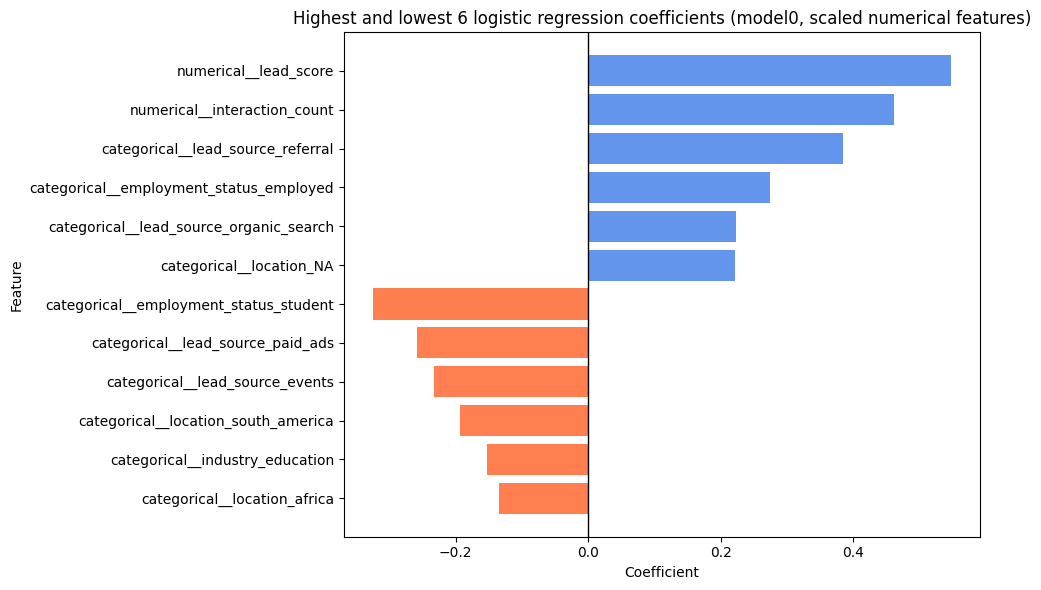

In [18]:
# Feature importance visualization: plot highest and lowest coefficients of model0

coef_df = pd.DataFrame(
    sorted_feature_coef0.items(),
    columns=['feature', 'coefficient']
)

plot_df = pd.concat(
    [
        coef_df.nlargest(6, 'coefficient'),
        coef_df.nsmallest(6, 'coefficient')
    ],
    ignore_index=True
)

colors = np.where(plot_df['coefficient'] > 0, 'cornflowerblue', 'coral')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
ax.set_title('Highest and lowest 6 logistic regression coefficients (model0, scaled numerical features)')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Feature')
fig.tight_layout()
plt.show();

In [19]:
# Q4. Train a logistic regression model - v2, no numerical standardization

dv = DictVectorizer(sparse=False)
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

model1 = LogisticRegression(solver='liblinear', 
                            C=1.0, 
                            max_iter=1000, 
                            random_state=42)
model1.fit(X_train, y_train)

# Compute accuracy on validation set
y_pred1 = model1.predict(X_val)
accuracy1 = (y_pred1 == y_val).mean()
print(f'Validation accuracy of model1, no numerical standardization: {accuracy1:.2f}')

Validation accuracy of model1, no numerical standardization: 0.65


In [20]:
print('model1 (logistic regression model with no numerical standardization):')
print(f'\nFeatures after one-hot encoding: {dv.get_feature_names_out()}')
print(f'\nIntercept: {model1.intercept_[0]}')
print(f'\nCoefficients: {model1.coef_[0]}')

model1 (logistic regression model with no numerical standardization):

Features after one-hot encoding: ['annual_income' 'employment_status=NA' 'employment_status=employed'
 'employment_status=self_employed' 'employment_status=student'
 'employment_status=unemployed' 'industry=NA' 'industry=education'
 'industry=finance' 'industry=healthcare' 'industry=manufacturing'
 'industry=retail' 'industry=technology' 'interaction_count' 'lead_score'
 'lead_source=NA' 'lead_source=events' 'lead_source=organic_search'
 'lead_source=paid_ads' 'lead_source=referral' 'lead_source=social_media'
 'location=NA' 'location=africa' 'location=asia' 'location=europe'
 'location=north_america' 'location=south_america'
 'number_of_courses_viewed']

Intercept: -0.010838978497809097

Coefficients: [-4.57849985e-06 -5.83434850e-04  7.40346890e-03 -3.28471892e-03
 -8.04069170e-03 -6.33360193e-03 -4.41226767e-04 -2.95759734e-03
 -6.49404976e-04 -2.15453817e-03 -2.30751043e-03 -1.65985277e-03
 -6.68848037e-04  1.367

In [21]:
feature_coef1 = dict(zip(dv.get_feature_names_out(),
                         model1.coef_[0].round(3)))
sorted_feature_coef1 = dict(sorted(feature_coef1.items(),
                                   key=lambda item: item[1], 
                                   reverse=True))
sorted_feature_coef1

{'interaction_count': np.float64(0.137),
 'number_of_courses_viewed': np.float64(0.054),
 'lead_score': np.float64(0.011),
 'lead_source=referral': np.float64(0.009),
 'employment_status=employed': np.float64(0.007),
 'lead_source=organic_search': np.float64(0.007),
 'annual_income': np.float64(-0.0),
 'industry=NA': np.float64(-0.0),
 'lead_source=NA': np.float64(0.0),
 'location=NA': np.float64(0.0),
 'employment_status=NA': np.float64(-0.001),
 'industry=finance': np.float64(-0.001),
 'industry=technology': np.float64(-0.001),
 'location=europe': np.float64(-0.001),
 'industry=healthcare': np.float64(-0.002),
 'industry=manufacturing': np.float64(-0.002),
 'industry=retail': np.float64(-0.002),
 'location=africa': np.float64(-0.002),
 'location=asia': np.float64(-0.002),
 'employment_status=self_employed': np.float64(-0.003),
 'industry=education': np.float64(-0.003),
 'location=north_america': np.float64(-0.003),
 'lead_source=social_media': np.float64(-0.004),
 'location=south_ame

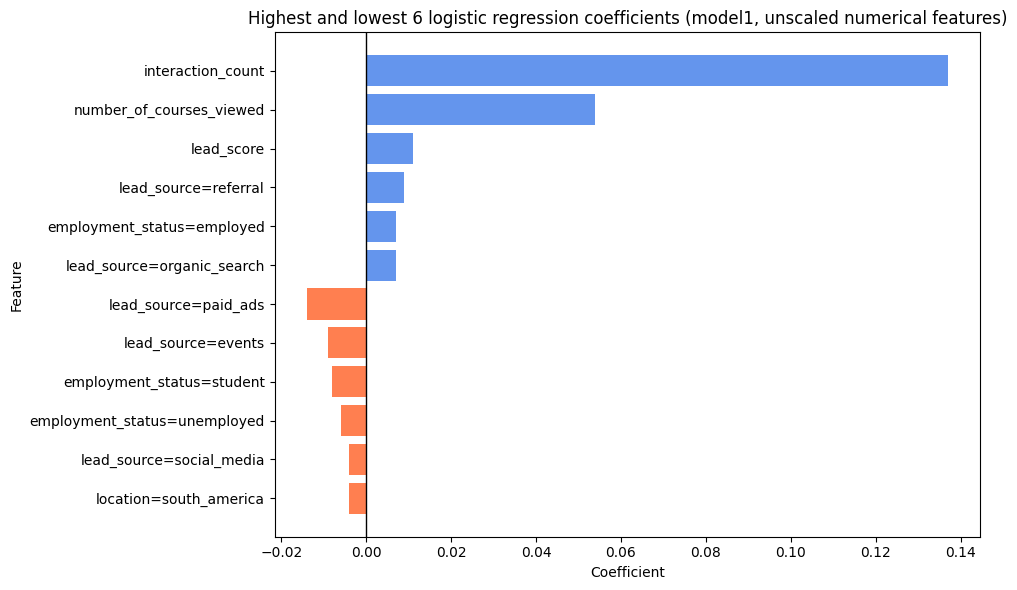

In [22]:
# Feature importance visualization: plot highest and lowest coefficients of model1, unscaled

coef_df = pd.DataFrame(
    sorted_feature_coef1.items(),
    columns=['feature', 'coefficient']
)

plot_df = pd.concat(
    [
        coef_df.nlargest(6, 'coefficient'),
        coef_df.nsmallest(6, 'coefficient')
    ],
    ignore_index=True
)

colors = np.where(plot_df['coefficient'] > 0, 'cornflowerblue', 'coral')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
ax.set_title('Highest and lowest 6 logistic regression coefficients (model1, unscaled numerical features)')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Feature')
fig.tight_layout()
plt.show();

The first logistic regression model, that with numeric features scaled using `StandardScaler()`, achieved a validation accuracy of 0.73. The second model, that with unscaled features, achieved a validation accuracy of 0.65. The feature importance rankings of the two versions of the model look similar, but have noticeable differences: in both models, `lead_score`, `interaction_count`, `lead_source=referral`, `employment_status=employed`, and `lead_source=organic_search` were among the top 6 features (i.e., the features with the most *positive* coefficients), but the second model also had `number_of_courses_viewed` as an important feature&mdash;the second most important to the model by absolute value of its coefficient. The bottom 6 features (i.e., the most *negative*) are also similar, but not identical, between the two versions of the model. These feature importance plots show the most useful (i.e., causing the largest positive or negative impact) features to the model.

In [23]:
categorical, numerical

(['lead_source', 'industry', 'employment_status', 'location'],
 ['annual_income',
  'number_of_courses_viewed',
  'interaction_count',
  'lead_score'])

In [24]:
# Q5. Feature elimination: find the least important feature,
# as measured by the difference in accuracy from the original model (named model1) when the feature is removed

def logistic_regression_feature_elim(df, drop_feature):
    df = df.drop(columns=drop_feature)
    new_categorical = [col for col in categorical if col != drop_feature]
    new_numerical = [col for col in numerical if col != drop_feature]

    df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
    df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train['converted'].values
    y_val = df_val['converted'].values
    y_test = df_test['converted'].values

    del df_train['converted']
    del df_val['converted']
    del df_test['converted']
    
    preprocessor = ColumnTransformer([
        ('categorical', OneHotEncoder(handle_unknown='ignore'), new_categorical)
    ], remainder='passthrough')

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='liblinear', 
                                          C=1.0, 
                                          max_iter=1000, 
                                          random_state=42))
    ])
    
    model.fit(df_train, y_train)
    accuracy = model.score(df_val, y_val)
    
    return accuracy

features = categorical + numerical
acc_original = accuracy1
acc_dict = {}

for f in features:
    accuracy = logistic_regression_feature_elim(df, drop_feature=f)
    acc_dict[f] = (accuracy, accuracy - acc_original)

for feature, (accuracy, diff) in acc_dict.items():
    print(f'Feature excluded: {feature}, accuracy: {accuracy}, diff from original accuracy: {accuracy - acc_original:.6f}')
    
scores = pd.DataFrame.from_dict(acc_dict, orient='index',
                                columns=['accuracy', 'diff_from_original']).sort_values('diff_from_original')

scores

Feature excluded: lead_source, accuracy: 0.642, diff from original accuracy: -0.003000
Feature excluded: industry, accuracy: 0.645, diff from original accuracy: 0.000000
Feature excluded: employment_status, accuracy: 0.645, diff from original accuracy: 0.000000
Feature excluded: location, accuracy: 0.645, diff from original accuracy: 0.000000
Feature excluded: annual_income, accuracy: 0.724, diff from original accuracy: 0.079000
Feature excluded: number_of_courses_viewed, accuracy: 0.643, diff from original accuracy: -0.002000
Feature excluded: interaction_count, accuracy: 0.601, diff from original accuracy: -0.044000
Feature excluded: lead_score, accuracy: 0.644, diff from original accuracy: -0.001000


,accuracy,diff_from_original
interaction_count,0.601,-0.044
lead_source,0.642,-0.003
number_of_courses_viewed,0.643,-0.002
lead_score,0.644,-0.001
location,0.645,0.000
employment_status,0.645,0.000
industry,0.645,0.000
annual_income,0.724,0.079


Out of `lead_source`, `number_of_courses_viewed`, and `interaction_count`, the feature resulting in the smallest difference from the original accuracy when removed from the model is `number_of_courses_viewed`. Of the three, it is the least useful feature to the model.

In [133]:
# Q6. Finding optimal regularization parameter C for logistic regression model

for C in [0.000001, 0.00001, 0.0001, 0.001]:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='liblinear', 
                                          C=C, 
                                          max_iter=1000, 
                                          random_state=42))
    ])
    
    model.fit(df_train, y_train)
    accuracy = model.score(df_val, y_val)
    
    print(f'C: {C}, validation accuracy: {accuracy:.3f}')

C: 1e-06, validation accuracy: 0.598
C: 1e-05, validation accuracy: 0.598
C: 0.0001, validation accuracy: 0.611
C: 0.001, validation accuracy: 0.642
